In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline


In [2]:
df=pd.read_csv("customer_segmentation.csv")

In [3]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [6]:
df["Income"].isnull().mean()*100

np.float64(1.0714285714285714)

In [7]:
df.dropna(inplace=True)

In [8]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [9]:
df['Education'].value_counts()

,count
Education,
Graduation,1116
PhD,481
Master,365
2n Cycle,200
Basic,54


In [10]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,857
Together,573
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [11]:
df['Dt_Customer']=pd.to_datetime(df["Dt_Customer"],dayfirst=True )

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [13]:
df["Age"]=2026-df['Year_Birth']

In [14]:
df['Total_children']=df['Kidhome']+df['Teenhome']

In [15]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children'],
      dtype='object')

In [16]:
df['Total_spend']=df['MntWines']+df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']

In [17]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_children,Total_spend
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,3,11,1,69,0,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,3,11,0,72,2,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,3,11,0,61,0,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,3,11,0,42,1,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,3,11,0,45,1,422


In [18]:
currentDate = pd.to_datetime("2026-09-19")

In [19]:
df['Customer_since']=(currentDate-df['Dt_Customer']).dt.days

In [20]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_children,Total_spend,Customer_since
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,3,11,1,69,0,1617,5128
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,3,11,0,72,2,27,4578
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,3,11,0,61,0,776,4777
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,3,11,0,42,1,53,4604
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,3,11,0,45,1,422,4626


**Ploting Charts**

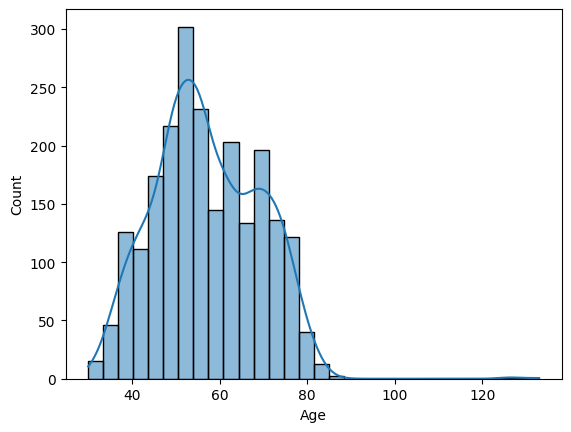

In [21]:
sns.histplot(df['Age'],bins=30,kde=True)
plt.show()

Most of the people are middle aged

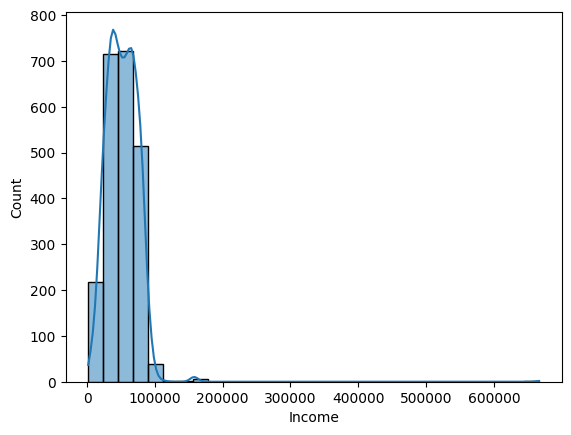

In [22]:
sns.histplot(df['Income'],bins=30,kde=True)
plt.show()

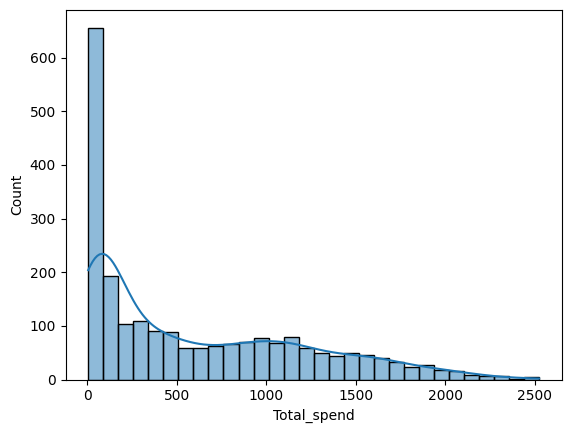

In [23]:
sns.histplot(df['Total_spend'],bins=30,kde=True)
plt.show()

Most of the datas are in lesspending side. Which is expected and normal

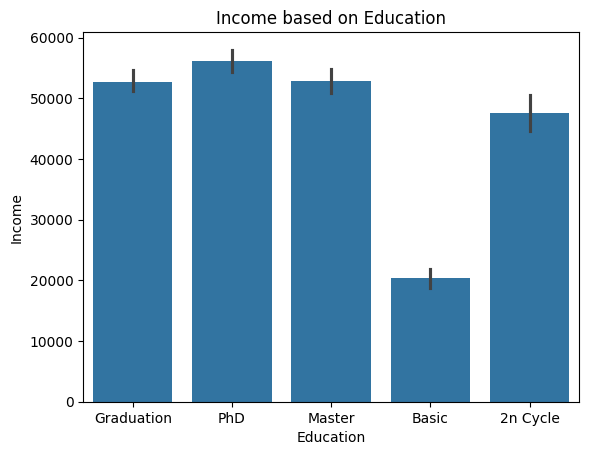

In [24]:
sns.barplot(x='Education',y='Income',data=df)
plt.title("Income based on Education")
plt.show()

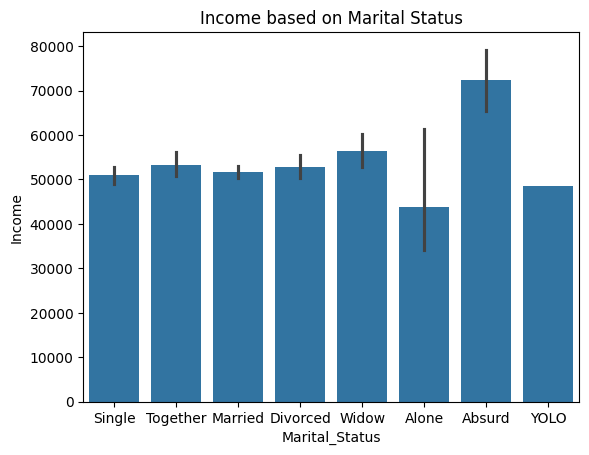

In [25]:
sns.barplot(x='Marital_Status',y='Income',data=df)
plt.title("Income based on Marital Status")
plt.show()

In [26]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children', 'Total_spend', 'Customer_since'],
      dtype='object')

In [27]:
corr=df[['Income','Age','Recency','Total_spend','NumWebPurchases','NumStorePurchases']]

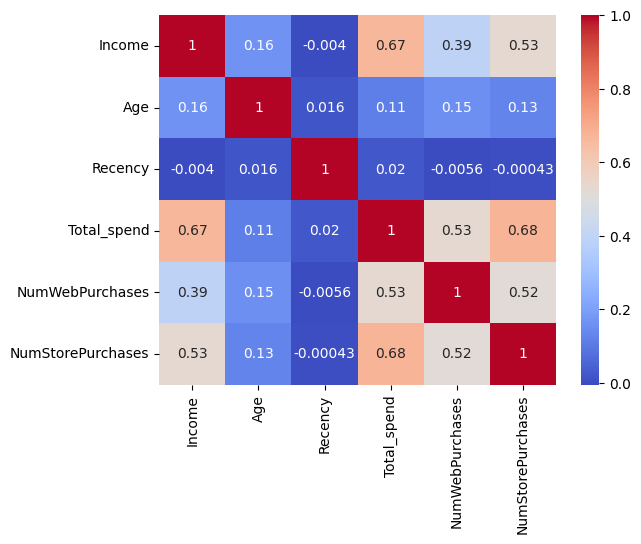

In [28]:
sns.heatmap(corr.corr(),annot=True,cmap='coolwarm')
plt.title
plt.show()

In [29]:
pivot_income=df.pivot_table(values='Income',index='Education',columns='Marital_Status',aggfunc='mean')

In [30]:
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


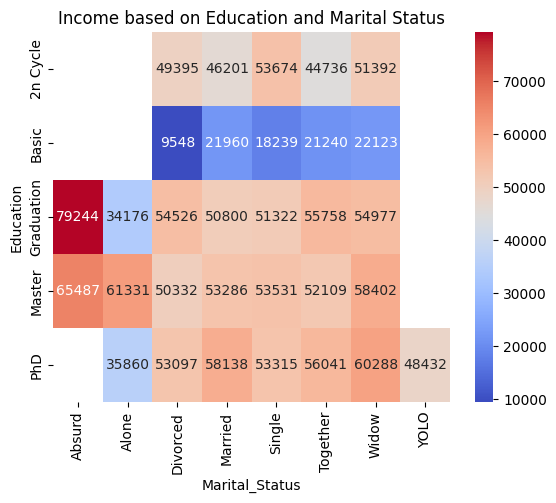

In [31]:
sns.heatmap(pivot_income,annot=True,fmt='.0f',cmap='coolwarm')
plt.title("Income based on Education and Marital Status")
plt.show()

**Model training and clustering**

In [32]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children', 'Total_spend', 'Customer_since'],
      dtype='object')

In [33]:
features=['Age','Income','Total_spend', 'NumWebPurchases', 'NumStorePurchases','Recency','NumWebVisitsMonth']

In [34]:
df_train=df[features]

In [35]:
df_train.head(5)

,Age,Income,Total_spend,NumWebPurchases,NumStorePurchases,Recency,NumWebVisitsMonth
0,69,58138.0,1617,8,4,58,7
1,72,46344.0,27,1,2,38,5
2,61,71613.0,776,8,10,26,4
3,42,26646.0,53,2,4,26,6
4,45,58293.0,422,5,6,94,5


In [36]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
scaled=sc.fit_transform(df_train)

In [37]:
scaled.shape

(2216, 7)

In [38]:
#Applying kmeans clustering
from sklearn.cluster import KMeans


In [39]:
k_n=range(2,10)
ssc=[]

for i in k_n:
    km=KMeans(n_clusters=i)
    km.fit(scaled)
    ssc.append(km.inertia_)

In [40]:
ssc

[10218.620143748774,
 9007.775913640156,
 8158.981757390416,
 7636.7584579145,
 7167.2620537699095,
 6778.848477705825,
 6514.697486766593,
 6182.323033191713]

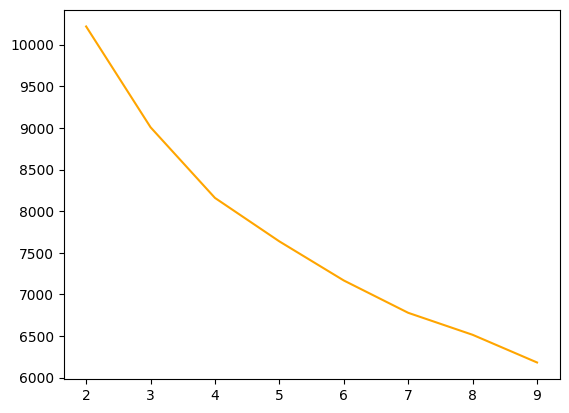

In [41]:
plt.plot(k_n,ssc,color='orange')
plt.show()


In [42]:
k_means=KMeans(n_clusters=6)
k_means.fit(scaled)

KMeans(n_clusters=6)

In [43]:
k_means.labels_

array([3, 5, 3, ..., 2, 1, 4], dtype=int32)

In [44]:
k_means.labels_.shape

(2216,)

In [45]:
df_train["Clusters"]=(k_means.labels_)

/tmp/ipykernel_794/2842199481.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train["Clusters"]=(k_means.labels_)


In [46]:
df_train.head(5)

,Age,Income,Total_spend,NumWebPurchases,NumStorePurchases,Recency,NumWebVisitsMonth,Clusters
0,69,58138.0,1617,8,4,58,7,3
1,72,46344.0,27,1,2,38,5,5
2,61,71613.0,776,8,10,26,4,3
3,42,26646.0,53,2,4,26,6,5
4,45,58293.0,422,5,6,94,5,0


In [47]:
df_train['Clusters'].value_counts()

,count
Clusters,
5,516
0,506
2,323
1,294
4,290
3,287


In [48]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(scaled)



In [49]:
pca_data.shape

(2216, 2)

In [50]:
pca_data

array([[ 1.1075188 , -0.21175951],
       [-1.33673385,  0.269839  ],
       [ 1.88227676, -1.01416098],
       ...,
       [ 1.1535966 ,  1.15056999],
       [ 1.88768024, -1.16073698],
       [-0.84182091, -0.15963623]])

In [51]:
df_train['PCA1'],df_train['PCA2']=pca_data[:,0],pca_data[:,1]

/tmp/ipykernel_794/1560774053.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['PCA1'],df_train['PCA2']=pca_data[:,0],pca_data[:,1]
/tmp/ipykernel_794/1560774053.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['PCA1'],df_train['PCA2']=pca_data[:,0],pca_data[:,1]


In [52]:
df_train.head()

,Age,Income,Total_spend,NumWebPurchases,NumStorePurchases,Recency,NumWebVisitsMonth,Clusters,PCA1,PCA2
0,69,58138.0,1617,8,4,58,7,3,1.107519,-0.211760
1,72,46344.0,27,1,2,38,5,5,-1.336734,0.269839
2,61,71613.0,776,8,10,26,4,3,1.882277,-1.014161
3,42,26646.0,53,2,4,26,6,5,-1.784359,-0.704928
4,45,58293.0,422,5,6,94,5,0,0.020363,1.235265


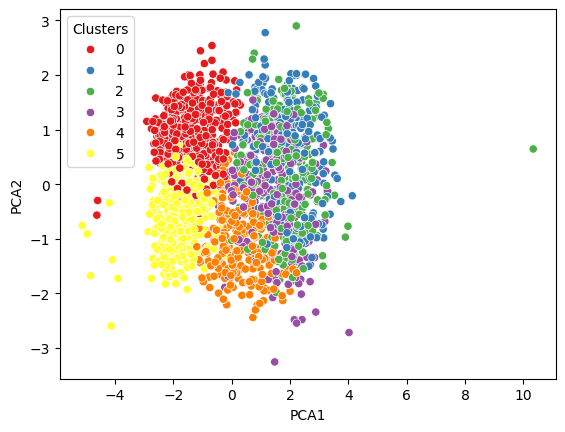

In [53]:
sns.scatterplot(x='PCA1',y='PCA2',data=df_train,hue='Clusters',palette='Set1')
plt.show()

In [54]:
import joblib

In [55]:
joblib.dump(k_means,"k_means_model.pkl")
joblib.dump(sc,"scaler.pkl")

['scaler.pkl']